# COGS 108 - EDA Checkpoint

## Authors

- Yuchen Hou: Background research, Writing – original draft, Writing – review & editing
- Minkyung Gwak: Background research, Writing – original draft, Writing – review & editing
- Nicolas Leedy: Background research, Data curation, Writing – review & editing
- Mowen Tan: Background research, Writing – original draft, Writing – review & editing
- Iris Liu: Background research, Writing – original draft

# Research Question

Are SAT Math and SAT Verbal medians significantly different across U.S. regions and between public vs. private universities in 2023?



## Background and Prior Work

Admission decisions at selective public universities shape not only the composition of the student body but also reflect institutional priorities and structural constraints. Within the University of California (UC) system, campuses receive applications from multiple residency categories, including California residents (in-state), domestic non-residents (out-of-state), and international applicants. These groups differ in tuition structure, financial contribution, and application volume, making comparisons of admission and enrollment outcomes particularly important. UC San Diego (UCSD), as a highly selective public research institution, provides a useful context for examining how admission rates and yield rates vary across residency groups. Public UC admissions datasets provide counts of applicants, admitted students, and enrolled students by residency status, enabling direct analysis of both admission probabilities and post-admission enrollment behavior.<a href=" ">1</a >

Prior research and institutional analyses have emphasized that understanding university access requires examining rates rather than only aggregate enrollment numbers. Summaries provided by the University of California Office of the President highlight how Proposition 209 reshaped admissions practices and underscore the importance of evaluating application, admission, and enrollment patterns separately.<a href="#ref3">3</a > These analyses suggest that raw enrollment totals alone may obscure underlying differences in admissions dynamics. Empirical work examining UC admissions policies similarly demonstrates that changes in student composition may arise from shifts in applicant behavior, selection processes, and institutional factors, motivating closer examination of admission probabilities across groups.<a href="#ref3">3</a >

Contemporary reporting further illustrates the relevance of residency-based comparisons. Recent coverage by the Los Angeles Times documents record numbers of California applicants alongside continued international enrollment growth, highlighting how applicant pools and admissions outcomes may evolve over time.<a href="#ref2">2</a > Policy commentary also points to structural barriers affecting California students, including disparities in academic preparation and access to advising resources, which may influence both application behavior and admissions outcomes.<a href="#ref4">4</a > Together, these discussions motivate systematic quantitative investigation of how admission rates and yield rates differ across residency categories.

Building on prior work, this project investigates how admission rates and yield rates differ for international, out-of-state, and in-state undergraduate applicants to UC San Diego between 2020 and 2025, and whether gaps between these groups have widened or narrowed over time.


References

<a name="ref1">1</a > University of California Admissions. UC San Diego First-Year Admit Data.
https://admission.universityofcalifornia.edu/campuses-majors/san-diego/first-year-admit-data.html

<a name="ref2">2</a > Los Angeles Times. UC Admissions and Residency Trends.
https://www.latimes.com/california/story/2025-07-28/uc-fall-2025-admissions-record-number-from-california-international-students-racial-diversity

<a name="ref3">3</a > Bleemer, Z. The Impact of Proposition 209 and Access-Oriented UC Admissions Policies.
https://www.ucop.edu/institutional-research-academic-planning/_files/uc-affirmative-action.pdf

<a name="ref4">4</a > CalMatters. Barriers Facing California Students Seeking UC Admission.
https://calmatters.org/commentary/2026/01/college-barriers-uc-california-students/

# Hypothesis


## Data

### Data overview

- Dataset #1
  - Dataset Name: IPEDS Admissions Data 2023 (Revised Values)
 
  - Link to the dataset: https://nces.ed.gov/ipeds/Search?query=&query2=&resultType=all&page=1&sortBy=date_desc&surveyComponents=Admissions%20(ADM)&collectionYears=2023-24

  - Number of observations: 1,973 universities

  - Number of variables: 101 columns

  - Description of the variables most relevant to this project  
	- UNITID: Unique school identifier used to merge datasets.
    - SATMT50: Median SAT Math section score for reported students (points, 200-800 scale).
    - SATVR50: Median SAT Verbal/Reading section score (used as SAT verbal proxy; points, 200-800 scale).
    - SATPCT: Percent of enrolled first-time students who submitted SAT scores (0-100).
    - SATMT25, SATMT75, SATVR25, SATVR75: 25th and 75th percentile SAT section scores.
    - APPLCN, ADMSSN, ENRLT: Applications, admissions, and enrollments (counts; used for context/quality checks).
    - X... columns (example XSATMT50): reporting/status flags for corresponding metrics.
    
   - Description of of any shortcomings this dataset has with respect to the project: SAT values are missing for many schools (especially under test-optional policies), so analysis sample is smaller after filtering. Data are school-level aggregates, not student-level observations; results are associative, not causal.


- Dataset #2
  - Dataset Name: IPEDS Institutional Characteristics / Header Data 2023
 
  - Link to the dataset: https://nces.ed.gov/ipeds/Search?query=&query2=&resultType=all&page=1&sortBy=date_desc&surveyComponents=Admissions%20(ADM)&collectionYears=2023-24

  - Number of observations: 6,163 institutions

  - Number of variables: 73 columns

  - Description of the variables most relevant to this project
	- UNITID: Unique school identifier used to merge with admissions data.
	- INSTNM: Institution name.
	- STABBR: State abbreviation.
	- OBEREG: Region code (used to build Northeast/Midwest/South/West groups).
	- CONTROL: Institution control (1 Public, 2 Private nonprofit, 3 Private for-profit), collapsed to Public vs Private in cleaning.
	- Other metadata fields exist (location, sector, size, URLs), but are not central to the main question.

- Descriptions of any shortcomings this dataset has with respect to the project: Region is coded numerically and must be recoded carefully to avoid misclassification.



In [3]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [4]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/COGS108/Group065_WI26/master/data/00-raw/adm2023_RV.csv', 'filename': 'adm2023_RV.csv' },
    { 'url': 'https://raw.githubusercontent.com/COGS108/Group065_WI26/master/data/00-raw/hd2023.csv', 'filename': 'hd2023.csv' }
]

get_data.get_raw(datafiles, destination_directory='data/00-raw/')

Overall Download Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                      

Successfully downloaded: adm2023_RV.csv



Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00, 13.23it/s]

Successfully downloaded: hd2023.csv


### University Admissions and SAT Outcomes by Region and Institution Type (IPEDS 2023 Combined Dataset)

This project combines two raw IPEDS 2023 files because neither file alone is sufficient for our research question. The admissions file (`adm2023_RV.csv`) contains SAT and admissions outcome variables but does not include the full contextual labels needed for grouped comparisons. The institutional header/characteristics file (`hd2023.csv`) provides those context variables, including institution name, state, region code, and control type. We merge these two sources by `UNITID` (IPEDS institution ID), so each final row still represents one institution but now includes both outcomes and grouping variables required for analysis.

The key outcome metrics are `SATMT50` and `SATVR50`, which are median SAT Math and SAT Verbal/Reading section scores at each institution. These are measured in SAT section points, where valid section values are generally between 200 and 800. We also retain `SATMT25`, `SATMT75`, `SATVR25`, and `SATVR75` to represent score spread within institutions. For admissions context, we keep `APPLCN` (number of applicants), `ADMSSN` (number admitted), and `ENRLT` (number enrolled), which are count variables. We also use `SATPCT` (0–100), the percentage of enrolled first-time students who submitted SAT scores, to evaluate how representative SAT statistics are at each institution.

The grouping variables come from institutional characteristics. `CONTROL` identifies institution control (public, private nonprofit, private for-profit), and `OBEREG` is the IPEDS region code. For this project, `OBEREG` is mapped to four broader U.S. regions (Northeast, Midwest, South, West). We also collapse institution control to `Public` vs `Private`. The reason is both conceptual and practical: after filtering out schools without usable SAT medians, one private subgroup (especially private for-profit) has very few institutions left, which makes separate subgroup comparisons unstable and noisy. Combining nonprofit and for-profit into a single private category gives more reliable group sizes for statistical comparison.

There are important limitations and potential biases. First, this is school-level aggregated data rather than student-level data, so analyses identify institutional associations rather than individual-level causal effects. Second, SAT fields have substantial missingness, likely related to test-optional and reporting practices, so missingness is probably systematic rather than random; this can bias the final sample. Third, `SATVR50` represents verbal/reading performance, not a direct writing score, so conclusions should use official variable definitions. Finally, collapsing private institution types improves stability but can hide differences between private nonprofit and private for-profit schools.

In [3]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLECELLS PER SECTION 

In [6]:
import pandas as pd
import numpy as np

# Load raw files
adm = pd.read_csv("data/00-raw/adm2023_RV.csv", low_memory=False)
hd = pd.read_csv("data/00-raw/hd2023.csv", low_memory=False)

# Merge admissions with institution metadata
df = adm.merge(
    hd[["UNITID", "INSTNM", "STABBR", "OBEREG", "CONTROL"]],
    on="UNITID",
    how="left"
)

print("Raw shape:", df.shape)
print("\nMissingness (%):")
print((df.isna().mean() * 100).sort_values(ascending=False).round(2))

# Keep columns used for analysis
df = df[[
    "UNITID", "INSTNM", "STABBR", "OBEREG", "CONTROL",
    "APPLCN", "ADMSSN", "ENRLT", "SATPCT",
    "SATVR50", "SATMT50", "SATVR25", "SATVR75", "SATMT25", "SATMT75"
]].copy()

# Convert numeric columns
num_cols = ["APPLCN", "ADMSSN", "ENRLT", "SATPCT", "SATVR50", "SATMT50", "SATVR25", "SATVR75", "SATMT25", "SATMT75"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Collapse control into Public vs Private only
df["control_group"] = df["CONTROL"].map({1: "Public", 2: "Private", 3: "Private"})

# Build 4-region labels from OBEREG
region_map = {
    1: "Northeast", 2: "Northeast",
    3: "Midwest", 4: "Midwest",
    5: "South", 6: "South",
    7: "West", 8: "West",
    9: "Outlying"
}
df["region"] = df["OBEREG"].map(region_map)

# Drop schools without SAT medians and keep valid groups
df_clean = df.dropna(subset=["SATMT50", "SATVR50"]).copy()
df_clean = df_clean[df_clean["control_group"].isin(["Public", "Private"])].copy()
df_clean = df_clean[df_clean["region"].isin(["Northeast", "Midwest", "South", "West"])].copy()

# Keep SAT values in valid section-score range
df_clean = df_clean[
    df_clean["SATMT50"].between(200, 800) &
    df_clean["SATVR50"].between(200, 800)
].copy()

# Optional context metrics
df_clean["admit_rate"] = np.where(df_clean["APPLCN"] > 0, df_clean["ADMSSN"] / df_clean["APPLCN"], np.nan)
df_clean["yield_rate"] = np.where(df_clean["ADMSSN"] > 0, df_clean["ENRLT"] / df_clean["ADMSSN"], np.nan)

# Save cleaned data
df_final = df_clean.drop(columns=["CONTROL", "OBEREG"], errors="ignore")
df_final.to_csv("data/02-processed/university_sat_region_control_2023.csv", index=False)


print(df_clean.shape)
df_final.head()

Raw shape: (1973, 105)

Missingness (%):
ENRLPTAN     96.45
ENRLFTAN     95.13
ENRLAN       92.90
ADMSSNAN     92.45
APPLCNAN     76.03
             ...  
XENRLT        0.00
XADMSSNUN     0.00
XADMSSNAN     0.00
XADMSSNW      0.00
CONTROL       0.00
Length: 105, dtype: float64
(983, 19)


,UNITID,INSTNM,STABBR,APPLCN,ADMSSN,ENRLT,SATPCT,SATVR50,SATMT50,SATVR25,SATVR75,SATMT25,SATMT75,control_group,region,admit_rate,yield_rate
0,100654,Alabama A & M University,AL,15628,10349.0,1956.0,24.0,480.0,460.0,420.0,540.0,390.0,520.0,Public,South,0.662209,0.189004
1,100663,University of Alabama at Birmingham,AL,10919,9655.0,2095.0,5.0,640.0,620.0,580.0,700.0,570.0,700.0,Public,South,0.884238,0.216986
2,100706,University of Alabama in Huntsville,AL,6074,4510.0,1176.0,6.0,650.0,680.0,595.0,700.0,600.0,740.0,Public,South,0.742509,0.260754
3,100724,Alabama State University,AL,5346,5113.0,951.0,9.0,489.0,477.0,444.0,538.0,421.0,531.0,Public,South,0.956416,0.185996
4,100751,The University of Alabama,AL,58418,44295.0,8279.0,18.0,640.0,640.0,590.0,700.0,580.0,700.0,Public,South,0.758242,0.186906


## Results

### Exploratory Data Analysis

#### Regional and Public/Private Differences in SAT Medians


#### Introduction to the graphs, what we are exploring and why (BETTER NAME FOR THIS LATER)
put an intro here is needed

### Yield Rates Graph Relevance 

This plot shows the yield rate(enrolled/admitted) of In-state, Out-of-State, and International from 2020-2025. These differences in yield rates are likely influenced by external factors such as geographic location, differences in tuition cost, and cultural practices. We expected that both Out-of-State and International would have a lower yield rate than In-State, however it was surprising to see Out-of_state having a lower yield rate than International applicants. This pattern may be influenced by factors we have not considered and should be researched further after finding whether or not these differences are statistically significant.  
### this need to change!!!

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Load processed dataset
df = pd.read_csv("data/02-processed/university_sat_region_control_2023.csv")

# Keep ordered categories for cleaner plots
region_order = ["Northeast", "Midwest", "South", "West"]
control_order = ["Public", "Private"]
df = df[df["region"].isin(region_order) & df["control_group"].isin(control_order)].copy()
df["region"] = pd.Categorical(df["region"], categories=region_order, ordered=True)
df["control_group"] = pd.Categorical(df["control_group"], categories=control_order, ordered=True)

print("Analysis shape:", df.shape)
display(df[["UNITID", "INSTNM", "region", "control_group", "SATMT50", "SATVR50"]].head())


Analysis shape: (983, 17)


,UNITID,INSTNM,region,control_group,SATMT50,SATVR50
0,100654,Alabama A & M University,South,Public,460.0,480.0
1,100663,University of Alabama at Birmingham,South,Public,620.0,640.0
2,100706,University of Alabama in Huntsville,South,Public,680.0,650.0
3,100724,Alabama State University,South,Public,477.0,489.0
4,100751,The University of Alabama,South,Public,640.0,640.0


### Heatmaps for compact summary


/tmp/ipykernel_425/2104696797.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mean_math = df.pivot_table(index="region", columns="control_group", values="SATMT50", aggfunc="mean").loc[region_order, control_order]
/tmp/ipykernel_425/2104696797.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mean_verbal = df.pivot_table(index="region", columns="control_group", values="SATVR50", aggfunc="mean").loc[region_order, control_order]


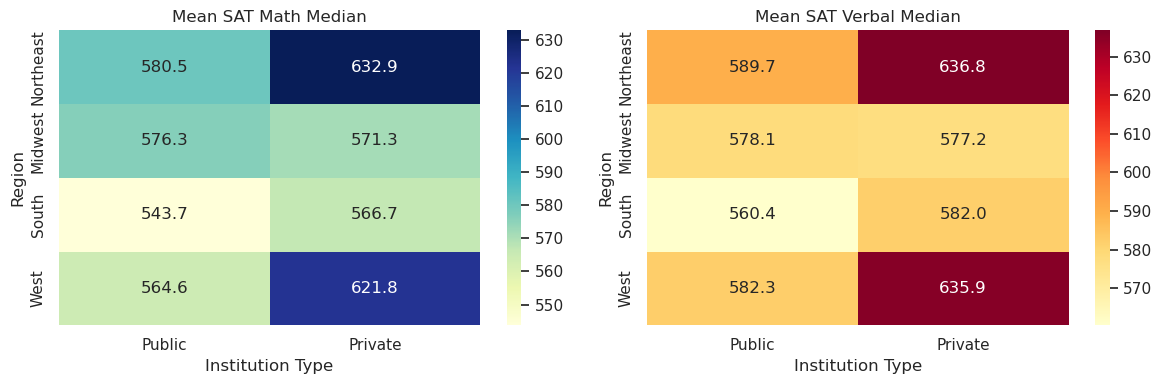

In [8]:
# Heatmaps for compact summary
mean_math = df.pivot_table(index="region", columns="control_group", values="SATMT50", aggfunc="mean").loc[region_order, control_order]
mean_verbal = df.pivot_table(index="region", columns="control_group", values="SATVR50", aggfunc="mean").loc[region_order, control_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(mean_math, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Mean SAT Math Median")
axes[0].set_xlabel("Institution Type")
axes[0].set_ylabel("Region")

sns.heatmap(mean_verbal, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Mean SAT Verbal Median")
axes[1].set_xlabel("Institution Type")
axes[1].set_ylabel("Region")

plt.tight_layout()
plt.show()

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [13]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

## Ethics 

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> Since we're using public, aggregated admissions statistics and data from UC San Diego instead of individual records, informed consent isn't applicable in this situation. However, we'll still make sure to be sensitive in our analysis since it can influence narratives and assumptions about specific applicant groups. We'll make sure to make responsible reports in order to avoid targeting and stigmatization.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> Biases could be introduced through reporting and definition differences throughout the years. For example, how the dataset defines words like "international", "out of state", and "in state" could change with different reporting cycles, and the university's formating could change as well. To limit biases, we'll rely on official definitions of that year and check for consistency in demnominators, and take into account any discontinuities in reporting.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> We'll only collect fields needed to analyze our research question, like the year, international/out of state/in state, and admission and yield rates. We won't use individual records, names, IDs, and application attributes. In the case that we do add subgroup breakdowns (ex. by major or by UCSD colleges), we'll use small cell supression and avoid creating tables where a group could be indirectly identified. 

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

> Since international/out of state/in state groups could easily be misused to argue that certain groups are more or less deserving of their acceptance/rejectance we'll present results as institutional outcomes rather than as judgements about individuals. We'll avoid using deficit language, attributing motivations, and explicitly state that many differences could reflect many factors (like application volume, financial aid, visa constraints, housing capacity) that aren't easily observable in aggregate reporting. 

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

> Though our source is public, our intersectional tables will be more sensitive than the original public data. We'll store files in a private page, avoid sharing raw derived tabs, and only sharing aggregated output when publishing. 

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

> Because we don't have individual level records and only publicly published aggregated, we can't remove an individual's data from the CDS.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

> We'll only keep anything needed for reproducibility, like links and citations and code to re download the CDS. However, we'll delete intermediate derived cross tabs, especially ones containing smaller cells. 

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

> Our interpretation of demographic differences can be shaped by our own assumptions. We'll make sure to ground conclusions in CDS documentation, check interpretations with peers and TAs, and avoid making normative judgements about international/in state/out of state groups. We'll also try to incorporate institutional context on what reported categories mean.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> The CDS isn't designed for causal inference and may not include confounders like applicant pool composition, policy changes, and reporting changes. We'll try to avoid causal language, check for discontinuities that suggest definitional changes, and refrain from making claims that can't be supported by aggregate reporting.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> We'll use consistent denominators and clearly label whether values are counts or percentages. We'll make sure to include totals and disclose when things are labeled as "unknown/not reported", avoid misleading axis scales, and avoid emphasizing categories that exaggerate differences.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

> Our analysis only uses aggregated counts by residency group and year, and doesn't use individual records or direct identifiers. We'll try not to infer or reconstruct individual outcomes. In the case we do introduce additional subgroup analyses, we'll suppress small cells and avoid publishing cross tabs that could lead to indirect identification

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> We'll keep our code and maintain a clear data provenance record like which CDS file and year we used, which tables, and which transformations were applied. Any recoding and suppression will be documented so results can be reproduced and corrected in case issues are found.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

> Though we're not building a predictive model, we'll still make sure to be mindful of analytical choices like grouping majors and creating categories, which could function like proxies that could unfairly shift narratives. We'll make sure to justify each grouping choice.

 - [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

> We'll present both counts and proportions and show multiple perspectives like the composition of admit versus admit rates within each subgroup. This makes sure it isn't easy for a single metric to create misleading conclusions. 

 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> We'll include a limitations section to emphasize aggregated reporting, definitional changes across years, missing data, small cell suppression, and the fact that our results are descriptive and not meant for individual level conclusions or causal claims. 

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

> We'll regularly review the published analysis for misinterpretation risks, especially if the university changes reporting formats and definitioins. If we find a figure is misused or misleading due to changes in definitions, we'll update or retract it. 

 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

> If we find that our output is misleading, creates stigmas, or creates privacy risks, we'll correct it and either add clarifications or remove it. We'll document changes to maintain transparency.

 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

> Since this is a published report and not a live system/model, rollback for us would mean removing or revising figures and tables and documenting changes in a log. 

 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

> A key use could be misusing demographic breakdowns to stereotype and create exclusionary arguments. We'll mitigate this by avoiding normative claims, providing contextual limitations, and adding a statement to only use it for appropriate use. 


## Team Expectations 

* Individual members are expected to complete their assigned parts of a given task on time.
* Members are expected to communicate to each other through text, Zoom, and in-person meetings every week.
* Members are expected to address conflicts calmly and focus on solutions beneficial to the team.
* Members are expected to support each other, share resources, and ask for help when needed to ensure the team succeeds. 

## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---| 
| 2/1  | 4:00 PM | Read & Think about COGS 108 expectations; brainstorm topics/questions  | Determine best form of communication; Discuss and decide on final project topic; discuss hypothesis; begin background research | 
| 2/3  |  8:00 PM |  Read 3–5 peer-reviewed articles related to International Student Admissions; summarize key findings in shared doc (at least 5 bullet points per person). | Discuss ideal dataset(s) and ethics; draft project proposal | 
| 2/4  | 7:00 PM | Edit, finalize, and submit proposal; Search for datasets  | Discuss Wrangling and possible analytical approaches; Assign group members to lead each specific part   |
| 2/14 | 8:00 PM | Being clear and think about what's the problem of the project proposal. Plan a workflow to refine everyones' own distibuted part. | Discuss how to refine our project proposal as a whole. Help each other (provide advice) to figure out some existing problems|
| 2/18  | 8:30 PM  | Work session：Data Integration: Merge multiple datasets; Initial Cleaning:Quantify missingness (% per column); decide between drop vs. imputation (mean/median/mode); document decision in notebook markdown. | Wrangling Review: Verify data integrity after merging; EDA Deep Dive: Analyze distributions of key variables & identify outliers; Refine Analysis Plan: Select specific statistical tests/models based on EDA trends.   |
| 2/22 | 8:00 PM | Advanced EDA: Generate correlation matrix & scatterplot matrices; Initial Hypothesis Testing.| Feature Selection: Discuss which variables to keep/drop based on correlation; Address Data Bias: Identify any systematic bias in the dataset (Ethics).|
| 2/28 | 8:00 PM | Feature Engineering: One-hot encoding for categorical data; Scaling/Normalization of numerical data | Define Analysis Pipeline: Finalize the choice of ML models (e.g., Regression vs. Classification); Assign members to code specific models. |
| 3/4  | 8:00 PM | Execute Baseline Models; Generate performance metrics (e.g., Accuracy, MSE, R-squared). | Model Evaluation: Compare performance across different models; Identify potential underfitting or overfitting; Complete project check-in. |
| 3/11  | 8:00 PM (Tentative) | Hyperparameter Tuning: Refine models for better performance; Finalize Visualizations (Final polished plots). | Result Interpretation: Explain the "Why" behind the results; Finalize Ethics & Privacy discussion based on final results; Relate findings back to original hypothesis; evaluate whether results support or reject it (statistical significance threshold α=0.05). Review project limitations. |
| 3/12  | 8:00 PM (Tentative) | Draft Results, Conclusion, and Discussion sections; Clean up Jupyter Notebook code and comments. | Full Project Review: Peer-edit the narrative for clarity and flow; Ensure reproducibility (Run the notebook from top to bottom). |
| 3/18  | Before 11:59 PM  | Final proofreading; Ensure all citations and references are formatted correctly. | Final Submission: Turn in Final Project & complete Group Project Surveys. |

Version Control & Workflow

We will use GitHub for version control. Each team member will work on separate feature branches and submit pull requests before merging into the main branch. All major analytical decisions (e.g., data cleaning strategies, model selection, evaluation metrics) will be documented in markdown cells within the notebook. We will ensure full reproducibility by running the notebook from top to bottom before submission.